# Notebook 08: Severity Classification (v2)

Binary classification: is this encounter high severity?

Notebook 03 explored severity on ACI-BENCH (only 67 samples and very skewed). Here we use the 1,200 LLM-extracted severity labels from mts_entities.json on the full MTS-Dialog training set. Labels with unclear values are dropped, then the clean labels are mapped to binary (high vs not-high).

In [1]:
import pandas as pd
import numpy as np
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import joblib

train_df = pd.read_csv('../data/raw/MTS-Dialog-TrainingSet.csv')

with open('../data/processed/mts_entities.json') as f:
    entities = json.load(f)

#Map severity labels - keep only clean values
train_df['severity_raw'] = train_df['ID'].astype(str).map(
    lambda x: str(entities.get(x, {}).get('severity', '')).strip().lower()
)

print("Raw severity distribution:")
print(train_df['severity_raw'].value_counts().to_string())

# Keep only clean labels
valid_labels = {'low', 'moderate', 'high'}
train_df = train_df[train_df['severity_raw'].isin(valid_labels)].copy()
train_df['severity_binary'] = (train_df['severity_raw'] == 'high').astype(int)

print(f"\nClean samples: {len(train_df)}")
print(f"High: {train_df['severity_binary'].sum()}, Not-high: {(~train_df['severity_binary'].astype(bool)).sum()}")
print(f"Prevalence: {train_df['severity_binary'].mean():.1%}")

Raw severity distribution:
severity_raw
moderate                   365
low                        347
                           235
high                       173
none                        38
unknown                     30
null                         6
low or moderate              2
mild                         1
not specified                1
low or moderate or high      1
low to moderate              1
n/a                          1

Clean samples: 885
High: 173, Not-high: 712
Prevalence: 19.5%


## Feature Engineering

In [2]:
# TF-IDF + dialogue features + entity features (excluding severity itself to avoid leakage)
tfidf = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1,2), min_df=2, max_df=0.95)
X_tfidf = tfidf.fit_transform(train_df['dialogue'])

def extract_dialogue_features(df):
    features = pd.DataFrame()
    features['word_count'] = df['dialogue'].str.split().str.len()
    features['turn_count'] = df['dialogue'].str.count(r'Doctor:|Patient:|\[doctor\]|\[patient\]')
    features['doctor_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Doctor|doctor).*?(?=Patient|patient|$)', x, re.DOTALL)).split()))
    features['patient_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Patient|patient).*?(?=Doctor|doctor|$)', x, re.DOTALL)).split()))
    features['avg_turn_length'] = features['word_count'] / features['turn_count'].clip(lower=1)
    return features

def extract_entity_features_no_severity(df, entities):
    """Entity features WITHOUT severity (since severity is the target)."""
    rows = []
    for _, row in df.iterrows():
        ent = entities.get(str(row['ID']), {})
        rows.append({
            'num_symptoms': len(ent.get('symptoms', [])),
            'num_diagnoses': len(ent.get('diagnoses', [])),
            'num_medications': len(ent.get('medications', [])),
            'has_chief_complaint': int(bool(ent.get('chief_complaint', ''))),
            'has_followup': int(bool(ent.get('follow_up_needed', False))),
        })
    return pd.DataFrame(rows, index=df.index).astype(float)

X_dialogue = extract_dialogue_features(train_df)
X_entity = extract_entity_features_no_severity(train_df, entities)
X_combined = hstack([X_tfidf, X_dialogue.values, X_entity.values])

scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform(X_combined)
y = train_df['severity_binary'].values

print(f"Feature matrix: {X_scaled.shape}")
print(f"  TF-IDF: 500, Dialogue: {X_dialogue.shape[1]}, Entity: {X_entity.shape[1]}")
print(f"  Note: severity excluded from entity features to prevent leakage")

Feature matrix: (885, 510)
  TF-IDF: 500, Dialogue: 5, Entity: 5
  Note: severity excluded from entity features to prevent leakage


## Model Comparison (5-fold CV)

In [3]:
models = {
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'SVM (Linear)': SVC(kernel='linear', class_weight='balanced', random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss', scale_pos_weight=4),
}

cv_results = {}
print("5-Fold Cross-Validation (F1)\n")
for name, model in models.items():
    if name == 'Naive Bayes':
        scores = cross_val_score(model, X_tfidf, y, cv=5, scoring='f1')
    else:
        scores = cross_val_score(model, X_scaled, y, cv=5, scoring='f1')
    cv_results[name] = scores
    print(f"{name:25s}  F1 = {scores.mean():.3f} (+/- {scores.std():.3f})")

5-Fold Cross-Validation (F1)

Naive Bayes                F1 = 0.240 (+/- 0.065)
Logistic Regression        F1 = 0.466 (+/- 0.043)
SVM (Linear)               F1 = 0.446 (+/- 0.058)
SVM (RBF)                  F1 = 0.463 (+/- 0.038)
Random Forest              F1 = 0.101 (+/- 0.087)
XGBoost                    F1 = 0.351 (+/- 0.070)


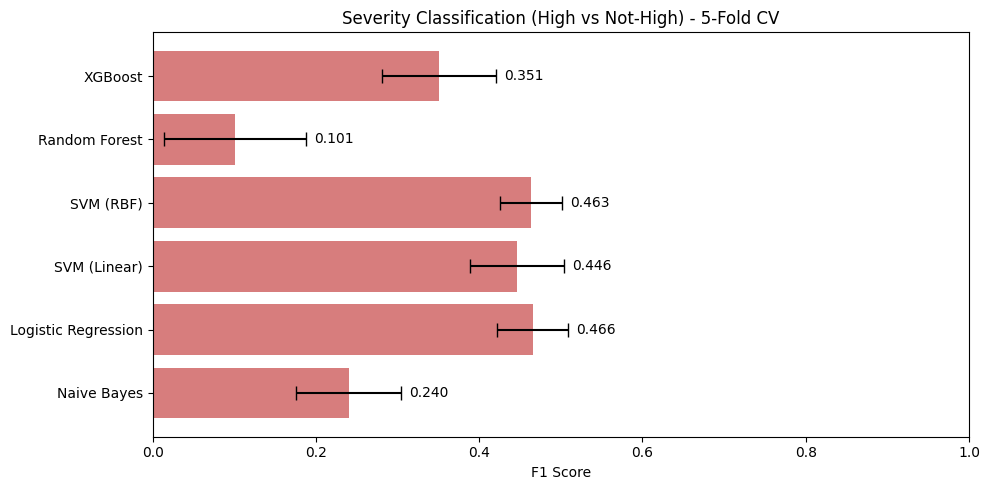

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds = [cv_results[n].std() for n in names]
bars = ax.barh(names, means, xerr=stds, capsize=5, color='indianred', alpha=0.8)
ax.set_xlabel('F1 Score')
ax.set_title('Severity Classification (High vs Not-High) - 5-Fold CV')
ax.set_xlim(0, 1.0)
for bar, mean, std in zip(bars, means, stds):
    ax.text(mean + std + 0.01, bar.get_y() + bar.get_height()/2, f'{mean:.3f}', va='center')
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

In [5]:
param_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(class_weight='balanced', random_state=42, max_iter=2000),
        'params': {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'liblinear']},
    },
    'SVM (Linear)': {
        'model': SVC(kernel='linear', class_weight='balanced', random_state=42),
        'params': {'C': [0.01, 0.1, 1, 10, 100]},
    },
    'Random Forest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=42),
        'params': {'n_estimators': [100, 200, 300], 'max_depth': [5, 10, 20, None]},
    },
}

tuned = {}
for name, config in param_grids.items():
    grid = GridSearchCV(config['model'], config['params'], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_scaled, y)
    tuned[name] = grid
    print(f"{name}:")
    print(f"  Best params: {grid.best_params_}")
    print(f"  Best F1: {grid.best_score_:.3f}\n")

Logistic Regression:
  Best params: {'C': 0.01, 'solver': 'lbfgs'}
  Best F1: 0.504

SVM (Linear):
  Best params: {'C': 0.01}
  Best F1: 0.511

Random Forest:
  Best params: {'max_depth': 5, 'n_estimators': 300}
  Best F1: 0.443



## Best Model: save and evaluate

Best model: SVM (Linear)
Best CV F1: 0.511
Params: {'C': 0.01}

Saved to models/severity_classifier.joblib

              precision    recall  f1-score   support

    Not High       0.94      0.65      0.77       712
        High       0.37      0.84      0.51       173

    accuracy                           0.68       885
   macro avg       0.66      0.74      0.64       885
weighted avg       0.83      0.68      0.72       885



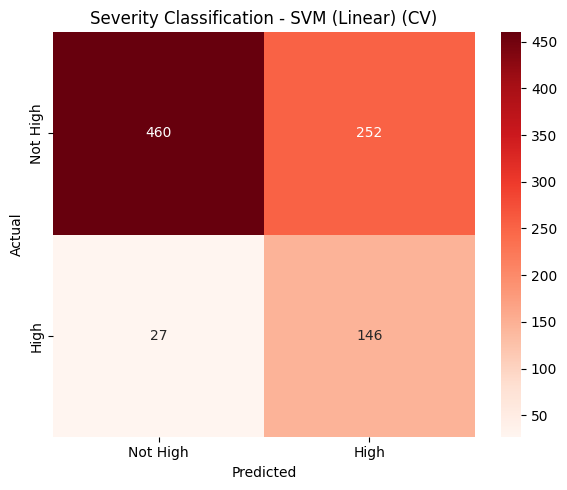

In [6]:
best_name = max(tuned, key=lambda k: tuned[k].best_score_)
best_model = tuned[best_name].best_estimator_
print(f"Best model: {best_name}")
print(f"Best CV F1: {tuned[best_name].best_score_:.3f}")
print(f"Params: {tuned[best_name].best_params_}")

joblib.dump({
    'model': best_model,
    'tfidf': tfidf,
    'scaler': scaler,
}, '../models/severity_classifier.joblib')
print(f"\nSaved to models/severity_classifier.joblib")

# Cross-validated confusion matrix
y_pred_cv = cross_val_predict(best_model, X_scaled, y, cv=5)

print(f"\n{classification_report(y, y_pred_cv, target_names=['Not High', 'High'])}")

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, y_pred_cv)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not High', 'High'],
            yticklabels=['Not High', 'High'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Severity Classification - {best_name} (CV)')
plt.tight_layout()
plt.show()

## ROC and Precision-Recall Curves

PR curve matters more here since only 19.5% of samples are high-severity. ROC can be misleading when classes are imbalanced.

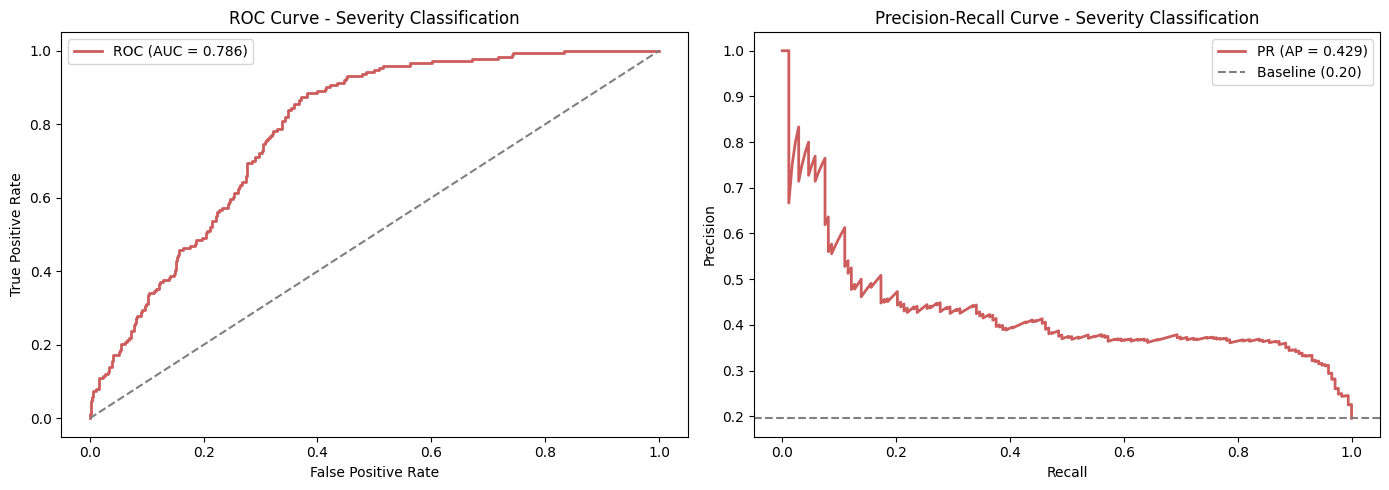

ROC AUC: 0.786
Average Precision: 0.429
(Baseline AP for random classifier: 0.195)


In [7]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

y_scores = cross_val_predict(best_model, X_scaled, y, cv=5, method='decision_function')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='indianred', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Severity Classification')
axes[0].legend()

precision, recall, _ = precision_recall_curve(y, y_scores)
ap = average_precision_score(y, y_scores)
axes[1].plot(recall, precision, color='indianred', lw=2, label=f'PR (AP = {ap:.3f})')
baseline = y.mean()
axes[1].axhline(y=baseline, linestyle='--', color='gray', label=f'Baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve - Severity Classification')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc:.3f}")
print(f"Average Precision: {ap:.3f}")
print(f"(Baseline AP for random classifier: {baseline:.3f})")

## Cohen's Kappa: LLM vs Keyword Severity Labels

How reliable are the LLM-generated severity labels we used for training?
Comparing them against a simple keyword-based labeling approach using Cohen's kappa.
Rough rules: kappa > 0.6 = substantial agreement, 0.4 to 0.6 = moderate, < 0.4 = weak.

In [8]:
from sklearn.metrics import cohen_kappa_score

# Reload full training set (before severity filtering)
full_df = pd.read_csv('../data/raw/MTS-Dialog-TrainingSet.csv')

# Keyword-based severity labeling (same logic as notebook 03)
high_keywords = ['cancer', 'carcinoma', 'tumor', 'stemi', 'stroke', 'seizure',
                 'fracture', 'surgery', 'emergency', 'chest pain', 'dyspnea',
                 'hemorrhage', 'bleeding', 'unconscious', 'sepsis', 'icu']
low_keywords = ['annual', 'routine', 'check-up', 'checkup', 'follow up',
                'refill', 'well visit', 'wellness', 'screening']

def keyword_severity(text):
    text_lower = text.lower()
    if any(kw in text_lower for kw in high_keywords):
        return 'high'
    elif any(kw in text_lower for kw in low_keywords):
        return 'low'
    return 'moderate'

full_df['kw_severity'] = full_df['dialogue'].apply(keyword_severity)
full_df['llm_severity'] = full_df['ID'].astype(str).map(
    lambda x: str(entities.get(x, {}).get('severity', '')).strip().lower()
)

# Keep only rows with clean LLM labels
valid = {'low', 'moderate', 'high'}
mask = full_df['llm_severity'].isin(valid)
kw = full_df.loc[mask, 'kw_severity'].values
llm = full_df.loc[mask, 'llm_severity'].values

kappa = cohen_kappa_score(kw, llm)
print(f"Cohen's kappa (keyword vs LLM): {kappa:.3f}")
print(f"Samples compared: {len(kw)}")

# Agreement breakdown
agreement = pd.crosstab(pd.Series(kw, name='Keyword'), pd.Series(llm, name='LLM'), margins=True)
print(f"\nCrosstab (Keyword vs LLM):")
print(agreement.to_string())
print(f"\nRaw agreement: {(kw == llm).mean():.1%}")

Cohen's kappa (keyword vs LLM): 0.017
Samples compared: 885

Crosstab (Keyword vs LLM):
LLM       high  low  moderate  All
Keyword                           
high        82   73       127  282
low          3   11        18   32
moderate    88  263       220  571
All        173  347       365  885

Raw agreement: 35.4%


Interpretation: kappa close to 0 means the two labeling methods basically disagree. This sets a ceiling on severity classifier performance, since the model can only learn whatever the training labels capture. Probably explains why follow-up prediction (F1=0.747) does much better than severity (F1=0.511): binary yes/no labels tend to be more consistent than severity which is more subjective.

## Calibration Plot

Does the model's predicted probability match the actual rate of high severity?

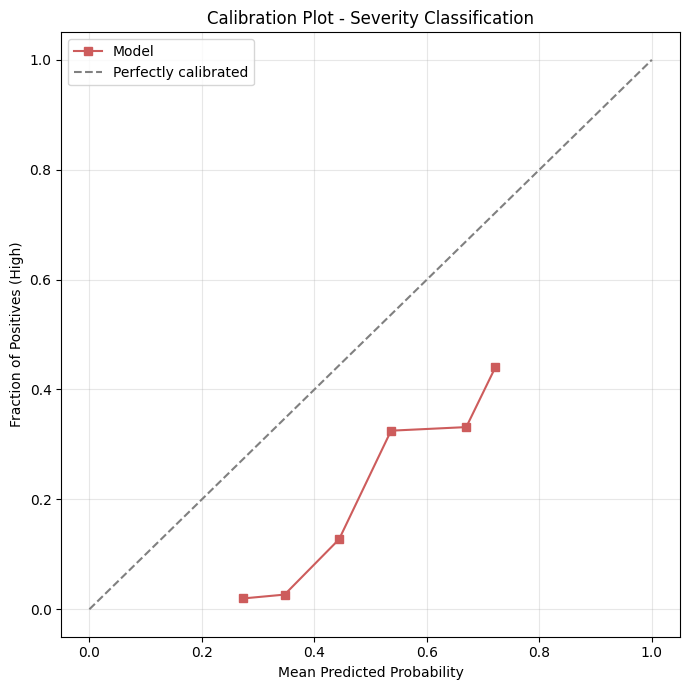

In [9]:
from sklearn.calibration import calibration_curve
from scipy.special import expit

# SVM decision_function -> pseudo-probability via sigmoid
y_prob = expit(y_scores)

prob_true, prob_pred = calibration_curve(y, y_prob, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(prob_pred, prob_true, 's-', color='indianred', label='Model')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly calibrated')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (High)')
ax.set_title('Calibration Plot - Severity Classification')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()